# Capstone Demo 

## Data Processing

In [29]:
import pandas as pd

df = pd.read_csv("../data/interim/alsfrs_core.csv")

In [31]:
df[["subject_id", "alsfrs_delta", "alsfrs_r_total"]].head()

,subject_id,alsfrs_delta,alsfrs_r_total
0,204,6.0,NaN
1,204,92.0,NaN
2,204,183.0,NaN
3,3301,5.0,35.0
4,3301,40.0,34.0


- Standardized column names
- Created longitudinal dataset (multiple observations per patient)

- `alsfrs_delta` (days since baseline visit)
- `alsfrs_r_total` (target variable)

## EDA

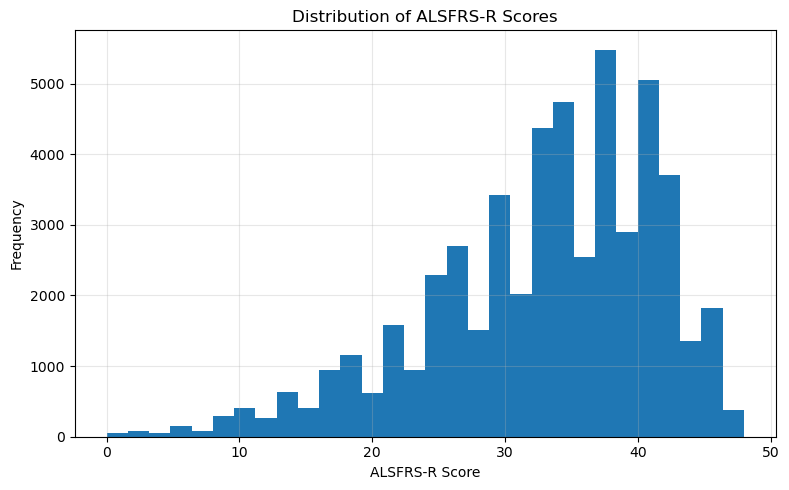

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["alsfrs_r_total"].dropna(), bins=30)

plt.title("Distribution of ALSFRS-R Scores")
plt.xlabel("ALSFRS-R Score")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

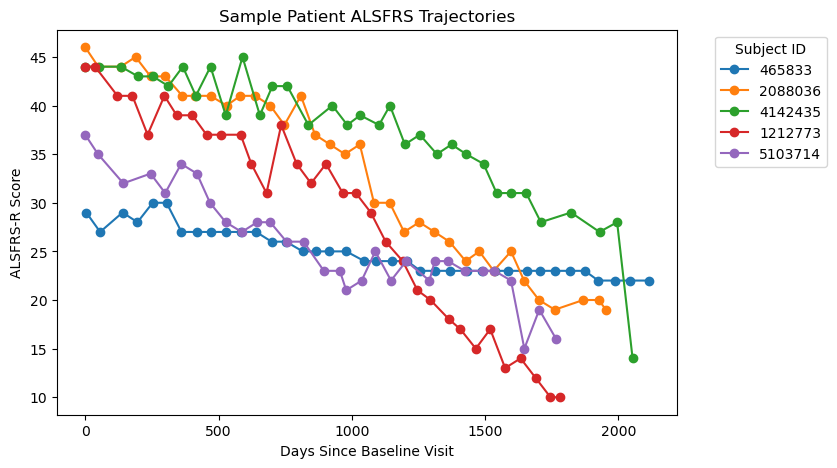

In [19]:
visit_counts = df.groupby("subject_id").size().sort_values(ascending=False)
sample_ids = visit_counts[visit_counts >= 5].head(5).index

plt.figure(figsize=(8,5))

for sid in sample_ids:
    subset = df[df["subject_id"] == sid].sort_values("alsfrs_delta")
    plt.plot(
        subset["alsfrs_delta"],
        subset["alsfrs_r_total"],
        marker="o",
        label=str(sid)
    )

plt.title("Sample Patient ALSFRS Trajectories")
plt.xlabel("Days Since Baseline Visit")
plt.ylabel("ALSFRS-R Score")
plt.legend(title="Subject ID", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

- Patient trajectories show  variability in progression rates
- Some patients decline rapidly, while others decline slowly over time

## Modeling

In [34]:
model_df = pd.read_csv("../data/processed/alsfrs_modeling_week5.csv")

In [33]:
model_df.head()

,subject_id,alsfrs_delta,visit_number,baseline_alsfrs_r_total,prev_alsfrs_r_total,time_since_first_visit,delta_from_prev_visit,age,sex,onset_delta,site_of_onset,alsfrs_r_total
0,3301,40.0,2,35.0,35.0,35.0,35.0,NaN,Male,-1049.0,Onset: Limb,34.0
1,3301,98.0,3,35.0,34.0,93.0,58.0,NaN,Male,-1049.0,Onset: Limb,32.0
2,3301,161.0,4,35.0,32.0,156.0,63.0,NaN,Male,-1049.0,Onset: Limb,32.0
3,3301,221.0,5,35.0,32.0,216.0,60.0,NaN,Male,-1049.0,Onset: Limb,34.0
4,3301,273.0,6,35.0,34.0,268.0,52.0,NaN,Male,-1049.0,Onset: Limb,32.0


In [35]:
metrics = pd.read_csv("../reports/week6_model_comparison_metrics.csv")
metrics

,model_name,mae,rmse,r2,n_train_rows,n_test_rows,n_train_patients,n_test_patients
0,naive_previous_visit,1.939792,3.012288,0.882153,36623,9218,4563,1141
1,linear_regression,1.829816,2.618816,0.910929,36623,9218,4563,1141
2,random_forest,1.821809,2.599467,0.912241,36623,9218,4563,1141
3,gradient_boosting,1.805794,2.573580,0.913980,36623,9218,4563,1141


- Naive baseline
- Linear regression
- Random forest
- Gradient Boosting